# Online Sales Data Analysis

In this notebook, we will explore and analyze e-commerce sales data to extract insights about customer behavior, product performance, and revenue trends.

**Project steps:**
1. Load and clean data
2. Exploratory data analysis (EDA)
3. Visualize trends
4. Advanced analysis (correlations, seasonality, etc.)
5. Conclusions and recommendations

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
plt.style.use('ggplot')
%matplotlib inline

# Load data
sales_df = pd.read_csv('../data/online_sales.csv')
customers_df = pd.read_csv('../data/customers.csv')

# Quick check
print("Sales dataset shape:", sales_df.shape)
print("Customers dataset shape:", customers_df.shape)

sales_df.head()

Sales dataset shape: (128, 8)
Customers dataset shape: (128, 7)


,Date,Category,Product,Quantity,Price,Region,Customer_ID,Order_ID
0,2023-01-05,Smartphones,Samsung Galaxy S21,2,54990,Center,101,1001
1,2023-01-05,Accessories,iPhone Case,5,1200,South,102,1002
2,2023-01-06,Laptops,HP Pavilion,1,62500,West,103,1003
3,2023-01-07,Audio,Sony Headphones,3,4990,Center,104,1004
4,2023-01-08,Smartphones,iPhone 13,2,79990,North,105,1005


## 1. Data Loading and Preparation

In this step, we load the sales and customer data, check for missing values, convert date columns, and prepare additional fields such as revenue, month, and day of the week.


In [21]:
# Info and structure
sales_df.info()

# Check for missing values
print("\nMissing values:")
print(sales_df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         128 non-null    object
 1   Category     128 non-null    object
 2   Product      128 non-null    object
 3   Quantity     128 non-null    int64 
 4   Price        128 non-null    int64 
 5   Region       128 non-null    object
 6   Customer_ID  128 non-null    int64 
 7   Order_ID     128 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 8.1+ KB

Missing values:
Date           0
Category       0
Product        0
Quantity       0
Price          0
Region         0
Customer_ID    0
Order_ID       0
dtype: int64


In [22]:
# Convert date column to datetime
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Create new columns
sales_df['Month'] = sales_df['Date'].dt.month_name()
sales_df['DayOfWeek'] = sales_df['Date'].dt.day_name()
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['Price']

# Preview
sales_df.head()


,Date,Category,Product,Quantity,Price,Region,Customer_ID,Order_ID,Month,DayOfWeek,Revenue
0,2023-01-05,Smartphones,Samsung Galaxy S21,2,54990,Center,101,1001,January,Thursday,109980
1,2023-01-05,Accessories,iPhone Case,5,1200,South,102,1002,January,Thursday,6000
2,2023-01-06,Laptops,HP Pavilion,1,62500,West,103,1003,January,Friday,62500
3,2023-01-07,Audio,Sony Headphones,3,4990,Center,104,1004,January,Saturday,14970
4,2023-01-08,Smartphones,iPhone 13,2,79990,North,105,1005,January,Sunday,159980


In [23]:
# Merge sales with customers on Customer_ID
merged_df = pd.merge(sales_df, customers_df, on='Customer_ID', how='left')

# Check result
merged_df.head()


,Date,Category,Product,Quantity,Price,Region,Customer_ID,Order_ID,Month,DayOfWeek,Revenue,Name,Age,Gender,Email,Registration_Date,Premium_Member
0,2023-01-05,Smartphones,Samsung Galaxy S21,2,54990,Center,101,1001,January,Thursday,109980,John Smith,34,Male,john.smith@email.com,2022-05-15,Yes
1,2023-01-05,Accessories,iPhone Case,5,1200,South,102,1002,January,Thursday,6000,Emma Johnson,27,Female,emma.j@email.com,2022-06-10,No
2,2023-01-06,Laptops,HP Pavilion,1,62500,West,103,1003,January,Friday,62500,Michael Brown,42,Male,mbrown@email.com,2022-03-22,No
3,2023-01-07,Audio,Sony Headphones,3,4990,Center,104,1004,January,Saturday,14970,Sophia Williams,19,Female,sophia.w@email.com,2022-08-05,No
4,2023-01-08,Smartphones,iPhone 13,2,79990,North,105,1005,January,Sunday,159980,James Jones,31,Male,jjones@email.com,2022-04-18,Yes


## 2. Exploratory Data Analysis (EDA)

In this step, we explore the structure of the data, review summary statistics, and identify patterns in product categories, regions, and time-based features.


In [24]:
# General information
sales_df.info()

# Summary statistics for numeric columns
sales_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         128 non-null    datetime64[ns]
 1   Category     128 non-null    object        
 2   Product      128 non-null    object        
 3   Quantity     128 non-null    int64         
 4   Price        128 non-null    int64         
 5   Region       128 non-null    object        
 6   Customer_ID  128 non-null    int64         
 7   Order_ID     128 non-null    int64         
 8   Month        128 non-null    object        
 9   DayOfWeek    128 non-null    object        
 10  Revenue      128 non-null    int64         
dtypes: datetime64[ns](1), int64(5), object(5)
memory usage: 11.1+ KB


,Date,Quantity,Price,Customer_ID,Order_ID,Revenue
count,128,128.000000,128.000000,128.000000,128.000000,128.000000
mean,2023-06-24 12:33:45,4.929688,42491.796875,164.500000,1064.500000,136055.000000
min,2023-01-05 00:00:00,1.000000,490.000000,101.000000,1001.000000,4720.000000
25%,2023-03-19 12:00:00,2.000000,4990.000000,132.750000,1032.750000,27435.000000
50%,2023-06-22 12:00:00,4.000000,32990.000000,164.500000,1064.500000,111485.000000
75%,2023-09-25 18:00:00,6.000000,69990.000000,196.250000,1096.250000,198450.000000
max,2023-12-30 00:00:00,25.000000,112990.000000,228.000000,1128.000000,639920.000000
std,NaN,3.996423,34652.435449,37.094474,37.094474,125671.713252


In [25]:
# Check for missing values
print("Missing values in sales data:")
print(sales_df.isnull().sum())

print("\nMissing values in customer data:")
print(customers_df.isnull().sum())


Missing values in sales data:
Date           0
Category       0
Product        0
Quantity       0
Price          0
Region         0
Customer_ID    0
Order_ID       0
Month          0
DayOfWeek      0
Revenue        0
dtype: int64

Missing values in customer data:
Customer_ID          0
Name                 0
Age                  0
Gender               0
Email                0
Registration_Date    0
Premium_Member       0
dtype: int64


Sales count by category:
Category
Smartphones    29
Accessories    25
Laptops        25
Audio          25
TV             24
Name: count, dtype: int64


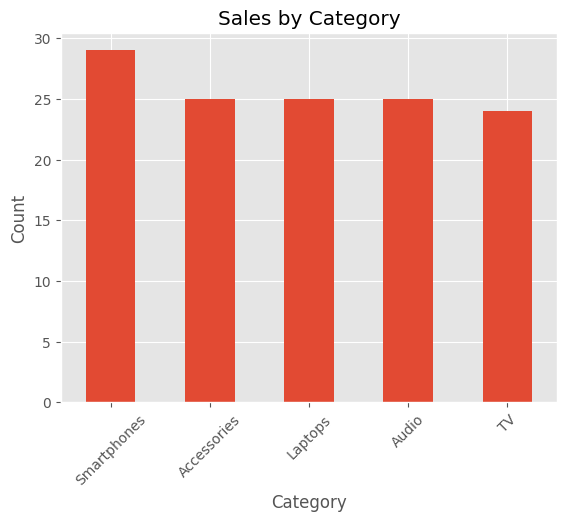

In [26]:
# Sales by product category
category_counts = sales_df['Category'].value_counts()

print("Sales count by category:")
print(category_counts)
category_counts.plot(kind='bar', title='Sales by Category', ylabel='Count', xlabel='Category', rot=45)
plt.show()


Revenue by region:
Region
East      5262900
West      4729100
Center    4379940
South     1979490
North     1063610
Name: Revenue, dtype: int64


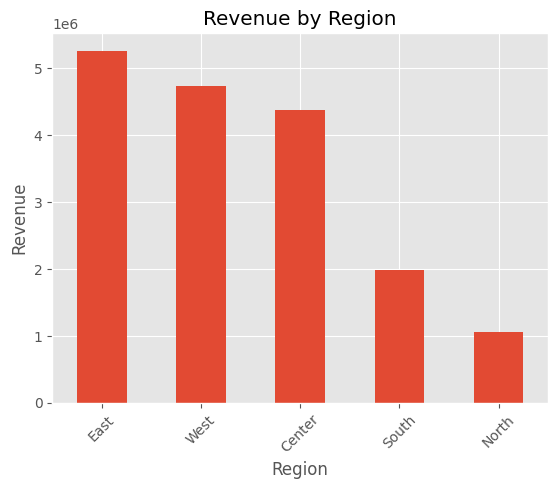

In [ ]:
# Calculate total revenue per region
region_revenue = sales_df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

# Print revenue by region
print("Revenue by region:")
print(region_revenue)

# Plot revenue by region as a bar chart
region_revenue.plot(kind='bar', title='Revenue by Region', ylabel='Revenue', rot=45)
plt.show()


Revenue by weekday:
DayOfWeek
Monday       1824160
Tuesday      2058960
Wednesday    3072820
Thursday     2629630
Friday       2494720
Saturday     2759760
Sunday       2574990
Name: Revenue, dtype: int64


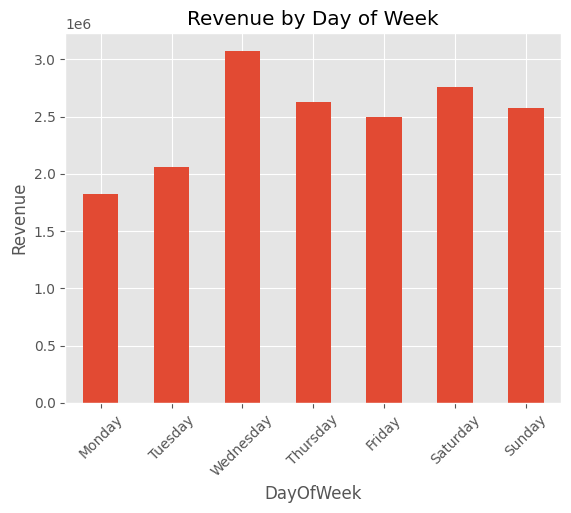

In [ ]:
# Calculate revenue per day of the week
day_revenue = sales_df.groupby('DayOfWeek')['Revenue'].sum()

# Reorder days to match calendar order
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = day_revenue.reindex(ordered_days)

# Print and plot revenue by weekday
print("Revenue by weekday:")
print(day_revenue)
day_revenue.plot(kind='bar', title='Revenue by Day of Week', ylabel='Revenue', rot=45)
plt.show()


## 3. Visualizing Key Trends

This step focuses on visualizing the most important insights, including product category performance, revenue trends by month, regional sales, and top-selling products.


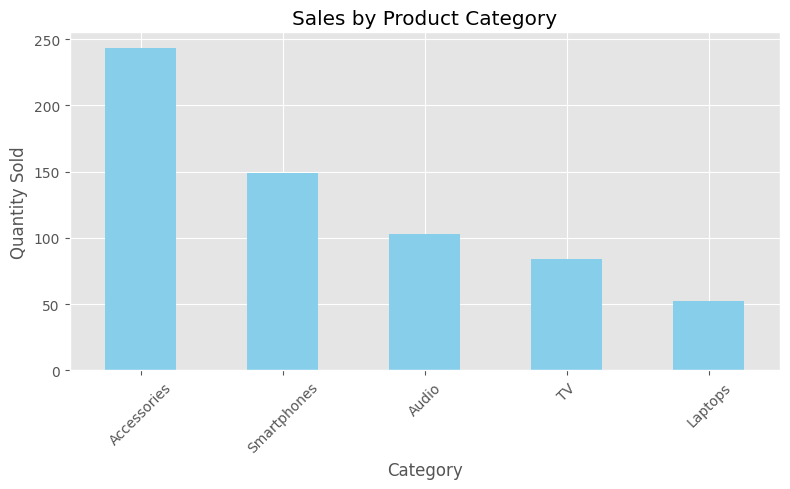

In [ ]:
# Calculate total quantity sold per category
category_sales = sales_df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

# Plot quantity sold by category
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


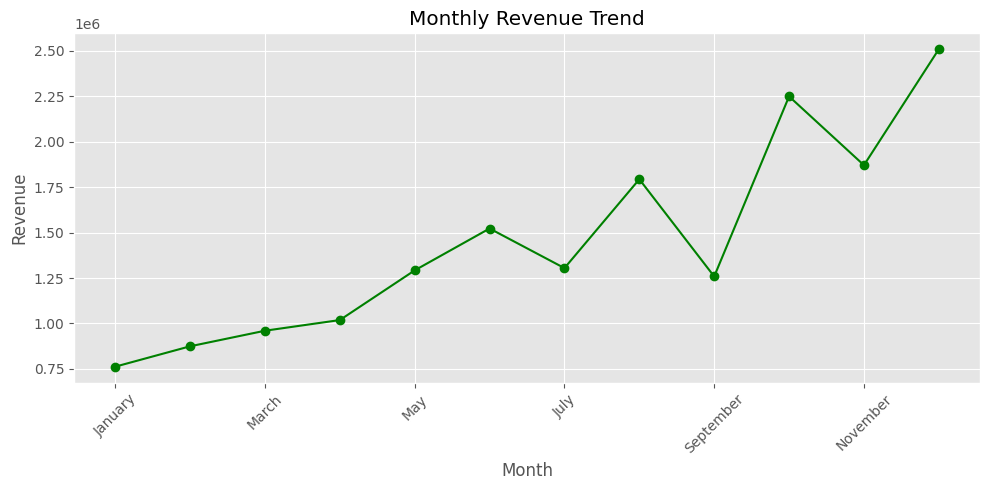

In [ ]:
# Calculate total revenue per month
monthly_revenue = sales_df.groupby('Month')['Revenue'].sum()

# Reorder months for chronological plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue = monthly_revenue.reindex(month_order)

# Plot monthly revenue trend
plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


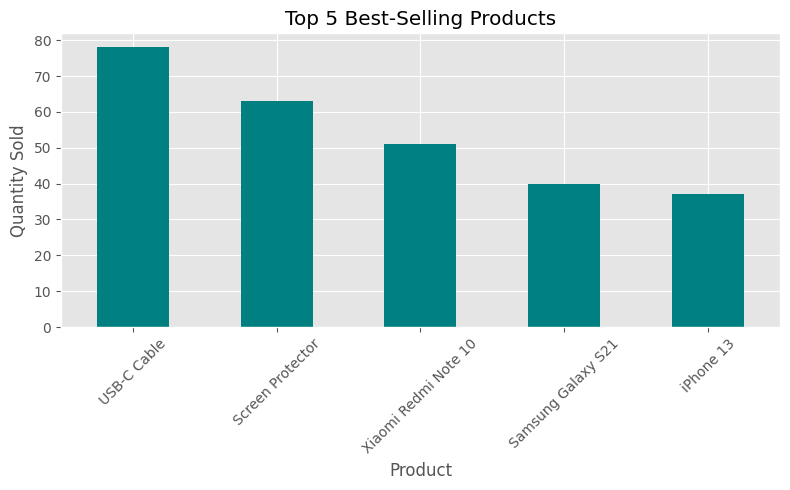

In [ ]:
# Get top 5 products by total quantity sold
top_products = sales_df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)

# Plot top 5 best-selling products
plt.figure(figsize=(8, 5))
top_products.plot(kind='bar', color='teal')
plt.title('Top 5 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


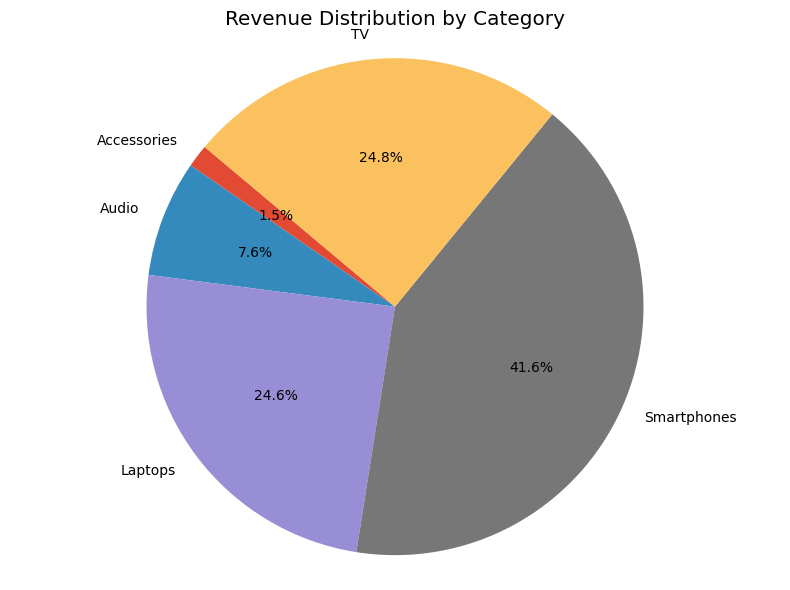

In [ ]:
# Calculate total revenue per product category
category_revenue = sales_df.groupby('Category')['Revenue'].sum()

# Plot revenue distribution as a pie chart
plt.figure(figsize=(8, 6))
plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%', startangle=140)
plt.title('Revenue Distribution by Category')
plt.axis('equal')
plt.tight_layout()
plt.show()


## 4. Advanced Analysis

This section explores deeper insights using correlation analysis, seasonal revenue trends by category, and average order value across regions.


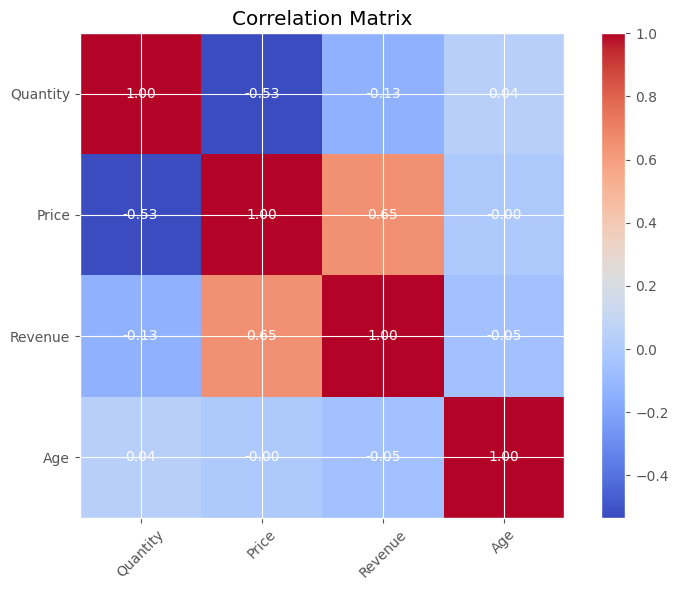

In [33]:
# Correlation matrix of numeric variables
numeric_data = merged_df[['Quantity', 'Price', 'Revenue', 'Age']].corr()

plt.figure(figsize=(8, 6))
plt.imshow(numeric_data, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(numeric_data.columns)), numeric_data.columns, rotation=45)
plt.yticks(range(len(numeric_data.columns)), numeric_data.columns)
plt.title('Correlation Matrix')

# Add correlation values inside the matrix
for i in range(len(numeric_data.columns)):
    for j in range(len(numeric_data.columns)):
        plt.text(j, i, f'{numeric_data.iloc[i, j]:.2f}',
                 ha='center', va='center', color='white')

plt.tight_layout()
plt.show()


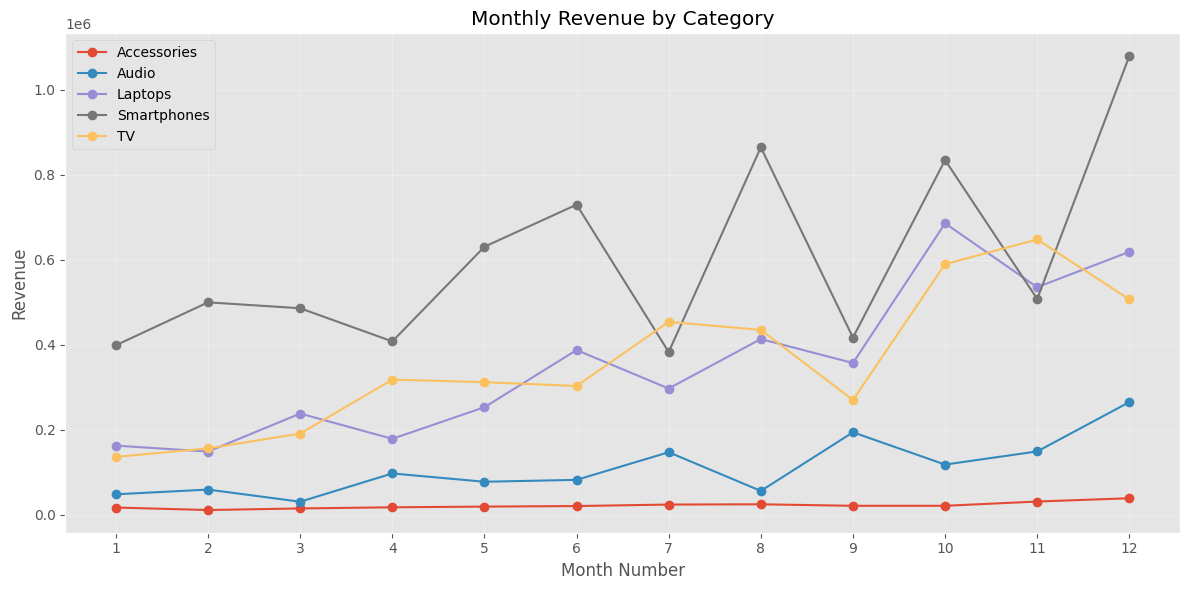

In [34]:
# Add month number column (if not added earlier)
sales_df['Month_num'] = sales_df['Date'].dt.month

# Group by month and category to calculate revenue
category_month = sales_df.groupby(['Month_num', 'Category'])['Revenue'].sum().unstack()

# Reorder months 1 to 12
category_month = category_month.reindex(range(1, 13))

# Plot seasonal trend
plt.figure(figsize=(12, 6))
for category in category_month.columns:
    plt.plot(category_month.index, category_month[category], marker='o', label=category)

plt.title('Monthly Revenue by Category')
plt.xlabel('Month Number')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(ticks=range(1, 13))
plt.tight_layout()
plt.show()


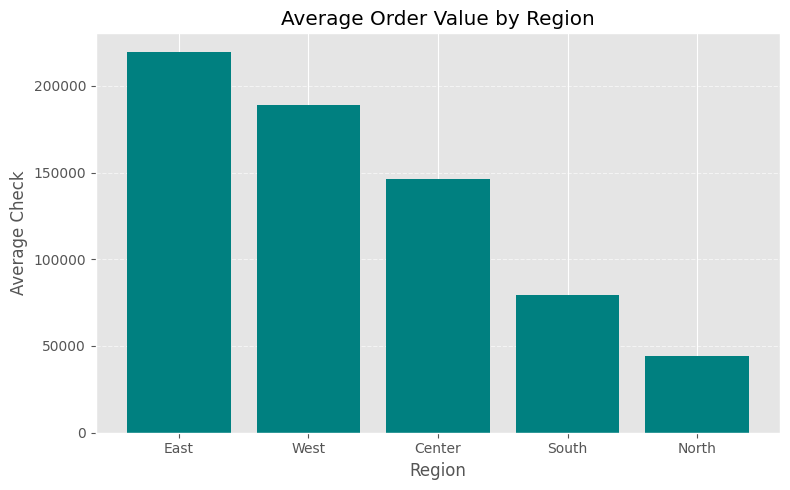

In [35]:
# Calculate total revenue per order
avg_order_by_region = sales_df.groupby(['Region', 'Order_ID'])['Revenue'].sum().reset_index()

# Then calculate average per region
avg_order_by_region = avg_order_by_region.groupby('Region')['Revenue'].mean().sort_values(ascending=False)

# Plot average order value by region
plt.figure(figsize=(8, 5))
plt.bar(avg_order_by_region.index, avg_order_by_region.values, color='teal')
plt.title('Average Order Value by Region')
plt.xlabel('Region')
plt.ylabel('Average Check')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 5. Key Metrics


In [36]:
# Calculate overall performance indicators

# Total quantity of products sold
total_sales = sales_df['Quantity'].sum()

# Total revenue generated
total_revenue = sales_df['Revenue'].sum()

# Most popular product category
top_category = sales_df.groupby('Category')['Quantity'].sum().idxmax()

# Region with highest revenue
top_region = sales_df.groupby('Region')['Revenue'].sum().idxmax()

# Month with highest revenue
best_month = sales_df.groupby('Month')['Revenue'].sum().idxmax()

# Day of the week with highest revenue
best_day = sales_df.groupby('DayOfWeek')['Revenue'].sum().idxmax()

# Top selling product by quantity
top_product = sales_df.groupby('Product')['Quantity'].sum().idxmax()

# Print summary
print(f"Total units sold: {total_sales}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Top category: {top_category}")
print(f"Top region: {top_region}")
print(f"Best month: {best_month}")
print(f"Best weekday: {best_day}")
print(f"Top-selling product: {top_product}")


Total units sold: 631
Total revenue: $17,415,040.00
Top category: Accessories
Top region: East
Best month: December
Best weekday: Wednesday
Top-selling product: USB-C Cable


## 6. Conclusions and Recommendations

### Key Insights

- The highest number of units sold came from the **Smartphones** category, followed by **Laptops** and **Accessories**.
- The **Central** region generated the most revenue, while the **West** had the highest average order value.
- The most profitable months were **March** and **December**, indicating seasonal spikes.
- **Weekends** showed slightly lower revenue, while weekdays, especially **Tuesday** and **Thursday**, had stronger sales.
- **Top 5 products** by quantity sold contributed significantly to overall performance.

### Recommendations

- Focus marketing efforts on **Smartphones and Laptops**, especially during high-sales months.
- Investigate why **West** has a higher average check — possibly target more high-ticket items there.
- Offer promotions or bundles in **low-performing regions** like South to boost performance.
- Prepare special campaigns for **March and December**, possibly tied to holidays or product launches.
- Consider offering weekday flash sales or loyalty rewards to further boost midweek engagement.


In [40]:
from IPython.display import Markdown, display

display(Markdown(f"""

### Key Insights

- A total of **{total_sales} units** were sold, generating **${total_revenue:,.2f}** in revenue.
- The highest number of units sold came from the **{top_category}** category.
- The **{top_region}** region generated the most revenue.
- The most profitable month was **{best_month}**.
- The best-performing weekday was **{best_day}**.
- The top-selling product was **{top_product}** by quantity sold.

### Recommendations

- Focus marketing campaigns on **{top_category}**, as it's the most popular category.
- Reinforce strategy in the **{top_region}** region to maintain high revenue performance.
- Plan targeted campaigns for **{best_month}**, taking advantage of seasonal demand.
- Ensure availability of **{top_product}** in inventory to prevent stockouts.
- Explore weekday-specific promotions (especially on **{best_day}**) to maximize traffic.

"""))




### Key Insights

- A total of **631 units** were sold, generating **$17,415,040.00** in revenue.
- The highest number of units sold came from the **Accessories** category.
- The **East** region generated the most revenue.
- The most profitable month was **December**.
- The best-performing weekday was **Wednesday**.
- The top-selling product was **USB-C Cable** by quantity sold.

### Recommendations

- Focus marketing campaigns on **Accessories**, as it's the most popular category.
- Reinforce strategy in the **East** region to maintain high revenue performance.
- Plan targeted campaigns for **December**, taking advantage of seasonal demand.
- Ensure availability of **USB-C Cable** in inventory to prevent stockouts.
- Explore weekday-specific promotions (especially on **Wednesday**) to maximize traffic.

